# ENM 5310 — Aurora precipitation fine-tuning (Head-only, publishable baseline)

Goal: train a small precipitation head on top of **frozen AuroraSmallPretrained**.

This notebook is meant to be the **"results" notebook** (training + eval + plots + saved checkpoints).


## 0) Config (edit only this cell)

In [1]:
from pathlib import Path
from datetime import datetime, timedelta

# Where your existing NetCDFs live (same folder you used)
DATA_DIR = Path("./downloads/era5")

def date_range(start: str, end: str):
    """Inclusive date range as YYYY-MM-DD strings."""
    s = datetime.fromisoformat(start)
    e = datetime.fromisoformat(end)
    out = []
    cur = s
    while cur <= e:
        out.append(cur.strftime("%Y-%m-%d"))
        cur += timedelta(days=1)
    return out

# Deadline-safe split
TRAIN_DATES = date_range("2023-01-01", "2023-01-20")
VAL_DATES   = date_range("2023-01-21", "2023-01-25")

# Training
EPOCHS = 3
LR = 1e-3
BATCH_SIZE = 1   # keep 1 for now (global 720x1440)

# GPU strategy
# If this OOMs, set BACKBONE_ON_GPU=False and we'll run Aurora on CPU and head on GPU.
BACKBONE_ON_GPU = False
HEAD_ON_GPU = True

# Output
OUT_DIR = Path("./runs/aurora_tp_head")
OUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = OUT_DIR / "precip_head.pt"

print("Config loaded.")
print("TRAIN_DATES:", len(TRAIN_DATES))
print("VAL_DATES:", len(VAL_DATES))


Config loaded.
TRAIN_DATES: 20
VAL_DATES: 5


In [2]:
################################
## Downloading data if needed ##
################################

from pathlib import Path
import cdsapi

c = cdsapi.Client()
out = Path("downloads/era5")
out.mkdir(parents=True, exist_ok=True)

def download_day(date_str):
    y, m, d = date_str.split("-")

    surf = out / f"{date_str}-surface-level.nc"
    atm  = out / f"{date_str}-atmospheric.nc"
    tp   = out / f"{date_str}-tp-hourly-01_to_06.nc"

    if not surf.exists():
        c.retrieve(
            "reanalysis-era5-single-levels",
            {
                "product_type": "reanalysis",
                "variable": [
                    "2m_temperature",
                    "10m_u_component_of_wind",
                    "10m_v_component_of_wind",
                    "mean_sea_level_pressure",
                ],
                "year": y, "month": m, "day": d,
                "time": ["00:00", "06:00", "12:00", "18:00"],
                "format": "netcdf",
            },
            str(surf),
        )

    if not atm.exists():
        c.retrieve(
            "reanalysis-era5-pressure-levels",
            {
                "product_type": "reanalysis",
                "variable": [
                    "temperature",
                    "u_component_of_wind",
                    "v_component_of_wind",
                    "specific_humidity",
                    "geopotential",
                ],
                "pressure_level": ["1000","850","500","200"],
                "year": y, "month": m, "day": d,
                "time": ["00:00", "06:00", "12:00", "18:00"],
                "format": "netcdf",
            },
            str(atm),
        )

    if not tp.exists():
        c.retrieve(
            "reanalysis-era5-single-levels",
            {
                "product_type": "reanalysis",
                "variable": ["total_precipitation"],
                "year": y, "month": m, "day": d,
                "time": [f"{h:02d}:00" for h in range(1, 7)],
                "format": "netcdf",
            },
            str(tp),
        )

    print("✓", date_str)


for d in TRAIN_DATES + VAL_DATES:
    download_day(d)


2025-12-17 22:17:37,115 INFO [2025-12-03T00:00:00Z] To improve our C3S service, we need to hear from you! Please complete this very short [survey](https://confluence.ecmwf.int/x/E7uBEQ/). Thank you.


✓ 2023-01-01


2025-12-17 22:17:37,714 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2025-12-17 22:17:37,715 INFO Request ID is 3e7edffa-f716-47ea-916a-9527fae29fb5
2025-12-17 22:17:37,840 INFO status has been updated to accepted
2025-12-17 22:17:46,799 INFO status has been updated to running
2025-12-17 22:17:52,020 INFO status has been updated to accepted
2025-12-17 22:17:59,875 INFO status has been updated to successful
2025-12-17 22:18:05,162 INFO Request ID is 13c04522-88c1-4b8f-a354-ac0c02ba3f60          
2025-12-17 22:18:05,297 INFO status has been updated to accepted
2025-12-17

✓ 2023-01-02


2025-12-17 22:19:20,798 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2025-12-17 22:19:20,799 INFO Request ID is c3773739-d2a5-4f87-9330-47ddc3df03b9
2025-12-17 22:19:20,914 INFO status has been updated to accepted
2025-12-17 22:19:34,769 INFO status has been updated to running
2025-12-17 22:19:54,038 INFO status has been updated to successful
2025-12-17 22:19:58,202 INFO Request ID is 2d2ff4a0-17fd-41c9-b5ff-9f039087449e        
2025-12-17 22:19:58,335 INFO status has been updated to accepted
2025-12-17 22:20:12,287 INFO status has been updated to running
2025-12-17 22

...

✓ 2023-01-23


2025-12-17 23:02:17,794 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2025-12-17 23:02:17,798 INFO Request ID is fa9d933f-9bd9-4a8d-866d-58570253e004
2025-12-17 23:02:17,927 INFO status has been updated to accepted
2025-12-17 23:02:31,713 INFO status has been updated to running
2025-12-17 23:02:39,433 INFO status has been updated to successful
2025-12-17 23:02:43,384 INFO Request ID is 5b674bc5-1757-4d97-b286-322bc7d8fb0b         
2025-12-17 23:02:43,514 INFO status has been updated to accepted
2025-12-17 23:02:57,349 INFO status has been updated to running
2025-12-17 2

✓ 2023-01-24


2025-12-17 23:04:01,923 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2025-12-17 23:04:01,924 INFO Request ID is cbd23dee-b0ef-462e-87ee-b50fc52fd185
2025-12-17 23:04:02,034 INFO status has been updated to accepted
2025-12-17 23:04:16,239 INFO status has been updated to running
2025-12-17 23:04:23,953 INFO status has been updated to successful
2025-12-17 23:04:27,483 INFO Request ID is 3b7df922-d8c9-4716-adf5-e4720e020a13          
2025-12-17 23:04:27,612 INFO status has been updated to accepted
2025-12-17 23:05:00,703 INFO status has been updated to running
2025-12-17 

✓ 2023-01-25


## 1) Imports + device

In [3]:
import json
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import xarray as xr

from aurora import Batch, Metadata
from aurora import AuroraSmallPretrained

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.7.0
cuda available: False
device: cpu


## 2) Load normalization stats (from your baseline)

In [4]:
STATS_PATH = Path("./tp_normalization.json")
assert STATS_PATH.exists(), "Missing tp_normalization.json (run baseline notebook Step 5)."

with open(STATS_PATH, "r") as f:
    stats = json.load(f)

MU = float(stats["mean"])
STD = float(stats["std"])
print("Loaded stats:", stats)
print("MU, STD:", MU, STD)


Loaded stats: {'target': 'log1p_tp_6h', 'mean': 0.0005497062811627984, 'std': 0.0019855170976370573, 'units': 'log(1 + meters)'}
MU, STD: 0.0005497062811627984 0.0019855170976370573


## 3) Helper: build Batch + target for one day

In [5]:
def build_paths(date_str: str):
    """Returns (surf_path, atm_path, tp_path, static_path)."""
    surf = DATA_DIR / f"{date_str}-surface-level.nc"
    atm  = DATA_DIR / f"{date_str}-atmospheric.nc"
    tp   = DATA_DIR / f"{date_str}-tp-hourly-01_to_06.nc"
    static = DATA_DIR / "static.nc"
    return surf, atm, tp, static


def build_batch(date_str: str) -> Batch:
    surf_path, atm_path, _, static_path = build_paths(date_str)
    assert surf_path.exists(), f"Missing {surf_path}"
    assert atm_path.exists(), f"Missing {atm_path}"
    assert static_path.exists(), f"Missing {static_path}"

    static_ds = xr.open_dataset(static_path)
    surf_ds   = xr.open_dataset(surf_path)
    atm_ds    = xr.open_dataset(atm_path)

    # 2 time steps (t0, t1)
    b = Batch(
        surf_vars={
            "2t":  torch.from_numpy(surf_ds["t2m"].values[:2][None]),
            "10u": torch.from_numpy(surf_ds["u10"].values[:2][None]),
            "10v": torch.from_numpy(surf_ds["v10"].values[:2][None]),
            "msl": torch.from_numpy(surf_ds["msl"].values[:2][None]),
        },
        static_vars={
            "z":   torch.from_numpy(static_ds["z"].values[0]),
            "slt": torch.from_numpy(static_ds["slt"].values[0]),
            "lsm": torch.from_numpy(static_ds["lsm"].values[0]),
        },
        atmos_vars={
            "t": torch.from_numpy(atm_ds["t"].values[:2][None]),
            "u": torch.from_numpy(atm_ds["u"].values[:2][None]),
            "v": torch.from_numpy(atm_ds["v"].values[:2][None]),
            "q": torch.from_numpy(atm_ds["q"].values[:2][None]),
            "z": torch.from_numpy(atm_ds["z"].values[:2][None]),
        },
        metadata=Metadata(
            lat=torch.from_numpy(surf_ds.latitude.values),
            lon=torch.from_numpy(surf_ds.longitude.values),
            time=(surf_ds.valid_time.values.astype("datetime64[s]").tolist()[1],),
            atmos_levels=tuple(int(l) for l in atm_ds.pressure_level.values),
        ),
    )

    static_ds.close(); surf_ds.close(); atm_ds.close()
    return b


def build_target(date_str: str) -> torch.Tensor:
    """Returns y_norm with shape [1,1,720,1440] on CPU."""
    _, _, tp_path, _ = build_paths(date_str)
    assert tp_path.exists(), f"Missing {tp_path}"

    tp_ds = xr.open_dataset(tp_path)
    tp = tp_ds["tp"]

    # Sum hours 1..6 (baseline)
    tp6h = tp.sum(dim="valid_time")

    y = torch.from_numpy(tp6h.values.astype("float32"))  # [H,W]
    y_log = torch.log1p(y)
    y_log_bchw = y_log[None, None].contiguous()  # [1,1,H,W]

    y_norm = (y_log_bchw - MU) / STD

    # Safety crop to match Aurora's 720 latitude grid
    y_norm = y_norm[:, :, :720, :].contiguous()

    tp_ds.close()
    return y_norm


## 4) Helper: pack Aurora features

In [6]:
def pack_surf_features(pred_batch: Batch) -> torch.Tensor:
    x2t  = pred_batch.surf_vars["2t"]
    x10u = pred_batch.surf_vars["10u"]
    x10v = pred_batch.surf_vars["10v"]
    xmsl = pred_batch.surf_vars["msl"]

    X = torch.cat([x2t, x10u, x10v, xmsl], dim=1).float()  # [B,4,H,W]

    # Per-channel standardization (per sample)
    mean = X.mean(dim=(2,3), keepdim=True)
    std  = X.std(dim=(2,3), keepdim=True).clamp_min(1e-6)
    X = (X - mean) / std

    return X


## 5) Model: Aurora (frozen) + Precip head (trainable)

In [7]:
class PrecipHead(nn.Module):
    def __init__(self, in_ch=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=1),
        )
    def forward(self, x):
        return self.net(x)


model = AuroraSmallPretrained(use_lora=False)
model.load_checkpoint("microsoft/aurora", "aurora-0.25-small-pretrained.ckpt")
model.eval()

for p in model.parameters():
    p.requires_grad_(False)

head = PrecipHead(in_ch=4)

if BACKBONE_ON_GPU and device.type == "cuda":
    model = model.to("cuda")
else:
    model = model.to("cpu")

if HEAD_ON_GPU and device.type == "cuda":
    head = head.to("cuda")
else:
    head = head.to("cpu")

print("Backbone device:", next(model.parameters()).device)
print("Head device:", next(head.parameters()).device)


Backbone device: cpu
Head device: cpu


## 6) Minimal training/eval loops (head-only)

Important rules (so we don't blow VRAM):
- Aurora forward runs under `torch.no_grad()` (backbone is frozen).
- We delete `pred` and `batch_*` every iteration.
- We only keep the head gradients.

Also: `torch.inference_mode()` creates *inference tensors* that can break autograd if you feed them into a trainable head.
So we use `no_grad()` here.


In [8]:
# Loss: make storms matter more than pure MSE-on-normalized (deadline-safe)
loss_fn = nn.SmoothL1Loss(beta=1.0)
opt = optim.Adam(head.parameters(), lr=LR)

def move_batch(b: Batch, dev: torch.device) -> Batch:
    return b.to(str(dev))


def corrcoef_map(a: torch.Tensor, b: torch.Tensor) -> float:
    """Pearson correlation between two [1,1,H,W] tensors."""
    a = a.detach().float().view(-1)
    b = b.detach().float().view(-1)
    a = a - a.mean()
    b = b - b.mean()
    denom = (a.std(unbiased=False) * b.std(unbiased=False)).clamp_min(1e-12)
    return float((a * b).mean() / denom)


@torch.no_grad()
def eval_one(date_str: str):
    model.eval(); head.eval()

    b = build_batch(date_str)
    y = build_target(date_str)  # CPU

    bb_dev = next(model.parameters()).device
    b_dev = move_batch(b, bb_dev)

    pred = model(b_dev)
    X = pack_surf_features(pred)

    h_dev = next(head.parameters()).device
    X = X.to(h_dev)
    y = y.to(h_dev)

    yhat = head(X)
    loss = float(loss_fn(yhat, y).item())

    # correlation (compute on CPU for stability)
    corr = corrcoef_map(yhat.to("cpu"), y.to("cpu"))

    del b, b_dev, pred, X, y, yhat
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return loss, corr


def train_one_epoch(dates):
    model.eval()  # frozen
    head.train()

    losses = []

    for i, date_str in enumerate(dates):
        b = build_batch(date_str)
        y = build_target(date_str)  # CPU

        bb_dev = next(model.parameters()).device
        b_dev = move_batch(b, bb_dev)

        # Aurora forward (no grads)
        with torch.no_grad():
            pred = model(b_dev)
            X = pack_surf_features(pred)

        h_dev = next(head.parameters()).device
        X = X.to(h_dev)
        y = y.to(h_dev)

        opt.zero_grad(set_to_none=True)
        yhat = head(X)
        loss = loss_fn(yhat, y)
        loss.backward()
        opt.step()

        losses.append(float(loss.item()))

        del b, b_dev, pred, X, y, yhat, loss
        if device.type == "cuda":
            torch.cuda.empty_cache()

        if (i % 1) == 0:
            print(f"  train sample {i+1}/{len(dates)} | loss {losses[-1]:.6f} | date {date_str}")

    return float(np.mean(losses)) if len(losses) else float("nan")


## 7) Run training + validation

Adds proper evaluation:
- Val loss
- Val correlation (Pearson corr between predicted/target maps)


In [9]:
print("TRAIN_DATES:", TRAIN_DATES[:3], "...", TRAIN_DATES[-3:])
print("VAL_DATES:", VAL_DATES)

history = {
    "train_loss": [],
    "val_loss": [],
    "val_corr": [],
}

for ep in range(EPOCHS):
    print(f"\n=== Epoch {ep+1}/{EPOCHS} ===")
    train_loss = train_one_epoch(TRAIN_DATES)
    history["train_loss"].append(train_loss)

    if len(VAL_DATES) > 0:
        vals = [eval_one(d) for d in VAL_DATES]
        val_loss = float(np.mean([v[0] for v in vals]))
        val_corr = float(np.mean([v[1] for v in vals]))
    else:
        val_loss = float("nan")
        val_corr = float("nan")

    history["val_loss"].append(val_loss)
    history["val_corr"].append(val_corr)

    print(f"Epoch {ep+1}: train_loss={train_loss:.6f} | val_loss={val_loss:.6f} | val_corr={val_corr:.4f}")

    torch.save(
        {
            "head_state_dict": head.state_dict(),
            "config": {
                "TRAIN_DATES": TRAIN_DATES,
                "VAL_DATES": VAL_DATES,
                "LR": LR,
                "EPOCHS": EPOCHS,
                "BACKBONE_ON_GPU": BACKBONE_ON_GPU,
                "HEAD_ON_GPU": HEAD_ON_GPU,
                "MU": MU,
                "STD": STD,
                "LOSS": "SmoothL1Loss(beta=1.0)",
            },
            "history": history,
        },
        CHECKPOINT_PATH,
    )
    print("Saved:", CHECKPOINT_PATH)

print("\nDone.")
print("history:", history)


TRAIN_DATES: ['2023-01-01', '2023-01-02', '2023-01-03'] ... ['2023-01-18', '2023-01-19', '2023-01-20']
VAL_DATES: ['2023-01-21', '2023-01-22', '2023-01-23', '2023-01-24', '2023-01-25']

=== Epoch 1/3 ===
  train sample 1/20 | loss 0.194262 | date 2023-01-01
  train sample 2/20 | loss 0.178703 | date 2023-01-02
  train sample 3/20 | loss 0.179259 | date 2023-01-03
  train sample 4/20 | loss 0.182324 | date 2023-01-04
  train sample 5/20 | loss 0.185781 | date 2023-01-05
  train sample 6/20 | loss 0.174118 | date 2023-01-06
  train sample 7/20 | loss 0.164450 | date 2023-01-07
  train sample 8/20 | loss 0.145717 | date 2023-01-08
  train sample 9/20 | loss 0.149627 | date 2023-01-09
  train sample 10/20 | loss 0.162053 | date 2023-01-10
  train sample 11/20 | loss 0.160156 | date 2023-01-11
  train sample 12/20 | loss 0.148250 | date 2023-01-12
  train sample 13/20 | loss 0.155730 | date 2023-01-13
  train sample 14/20 | loss 0.151874 | date 2023-01-14
  train sample 15/20 | loss 0.15237

## 8) Quick qualitative plot (one day)
This is what you can screenshot for your report: target vs prediction.

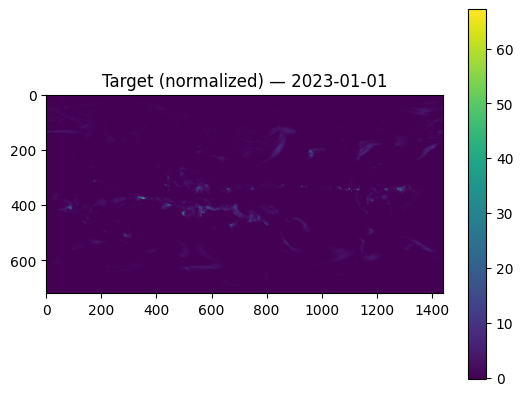

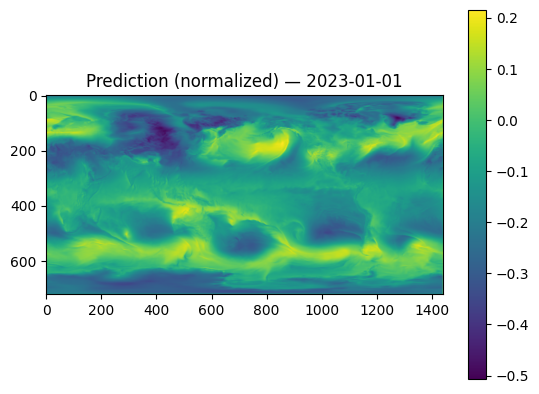

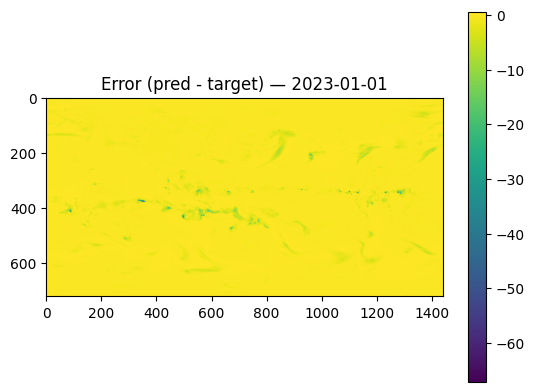

In [10]:
import matplotlib.pyplot as plt

def predict_map(date_str: str):
    model.eval(); head.eval()
    b = build_batch(date_str)
    y = build_target(date_str)  # CPU

    bb_dev = next(model.parameters()).device
    h_dev  = next(head.parameters()).device
    b_dev = move_batch(b, bb_dev)

    with torch.no_grad():
        pred = model(b_dev)
        X = pack_surf_features(pred).to(h_dev)
        yhat = head(X)

    yhat_cpu = yhat.detach().to("cpu").squeeze().numpy()
    y_cpu    = y.detach().to("cpu").squeeze().numpy()

    del b, b_dev, pred, X, yhat, y
    if device.type == "cuda":
        torch.cuda.empty_cache()

    return y_cpu, yhat_cpu


SHOW_DATE = TRAIN_DATES[0]
y_true, y_pred = predict_map(SHOW_DATE)

plt.figure()
plt.title(f"Target (normalized) — {SHOW_DATE}")
plt.imshow(y_true)
plt.colorbar()
plt.show()

plt.figure()
plt.title(f"Prediction (normalized) — {SHOW_DATE}")
plt.imshow(y_pred)
plt.colorbar()
plt.show()

plt.figure()
plt.title(f"Error (pred - target) — {SHOW_DATE}")
plt.imshow(y_pred - y_true)
plt.colorbar()
plt.show()


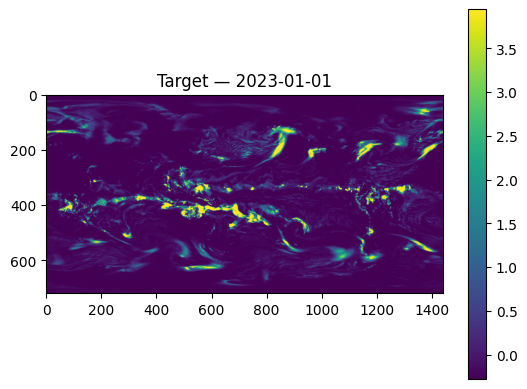

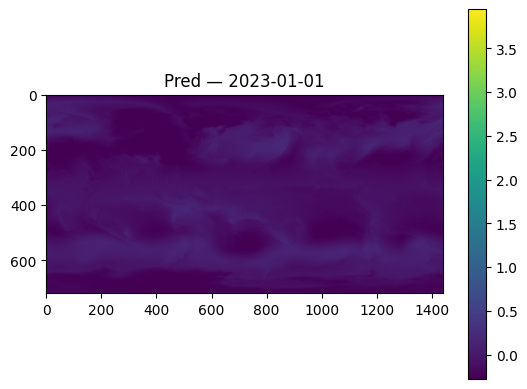

In [11]:
vmin = np.percentile(y_true, 1)
vmax = np.percentile(y_true, 99)

plt.figure(); plt.title(f"Target — {SHOW_DATE}"); plt.imshow(y_true, vmin=vmin, vmax=vmax); plt.colorbar(); plt.show()
plt.figure(); plt.title(f"Pred — {SHOW_DATE}");   plt.imshow(y_pred, vmin=vmin, vmax=vmax); plt.colorbar(); plt.show()


## 9) If GPU OOM happens
Only change in config:
- set `BACKBONE_ON_GPU = False`
- keep `HEAD_ON_GPU = True`

That runs Aurora on CPU and the head on GPU (still much faster than full CPU training).
